# Advertisement Effectiveness Analysis using A/B Testing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Cleaning

In [2]:
df=pd.read_csv("marketing_AB.csv")
df

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14
...,...,...,...,...,...,...,...
588096,588096,1278437,ad,False,1,Tuesday,23
588097,588097,1327975,ad,False,1,Tuesday,23
588098,588098,1038442,ad,False,3,Tuesday,23
588099,588099,1496395,ad,False,1,Tuesday,23


In [3]:
df.drop("Unnamed: 0", axis="columns",inplace=True)
df

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14
...,...,...,...,...,...,...
588096,1278437,ad,False,1,Tuesday,23
588097,1327975,ad,False,1,Tuesday,23
588098,1038442,ad,False,3,Tuesday,23
588099,1496395,ad,False,1,Tuesday,23


In [4]:
df.isna().sum()

user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["user id"].duplicated().sum()

np.int64(0)

In [7]:
df["converted"]=df["converted"].map({False:0,True:1})
df

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,0,130,Monday,20
1,1119715,ad,0,93,Tuesday,22
2,1144181,ad,0,21,Tuesday,18
3,1435133,ad,0,355,Tuesday,10
4,1015700,ad,0,276,Friday,14
...,...,...,...,...,...,...
588096,1278437,ad,0,1,Tuesday,23
588097,1327975,ad,0,1,Tuesday,23
588098,1038442,ad,0,3,Tuesday,23
588099,1496395,ad,0,1,Tuesday,23


In [8]:
df["test group"].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

In [9]:
df.describe(include="all")

,user id,test group,converted,total ads,most ads day,most ads hour
count,5.881010e+05,588101,588101.000000,588101.000000,588101,588101.000000
unique,NaN,2,NaN,NaN,7,NaN
top,NaN,ad,NaN,NaN,Friday,NaN
freq,NaN,564577,NaN,NaN,92608,NaN
mean,1.310692e+06,NaN,0.025239,24.820876,NaN,14.469061
std,2.022260e+05,NaN,0.156850,43.715181,NaN,4.834634
min,9.000000e+05,NaN,0.000000,1.000000,NaN,0.000000
25%,1.143190e+06,NaN,0.000000,4.000000,NaN,11.000000
50%,1.313725e+06,NaN,0.000000,13.000000,NaN,14.000000
75%,1.484088e+06,NaN,0.000000,27.000000,NaN,18.000000


## EDA

### Checking Experiment split

In [56]:
df["test group"].value_counts(normalize=True)

test group
ad     0.96
psa    0.04
Name: proportion, dtype: float64

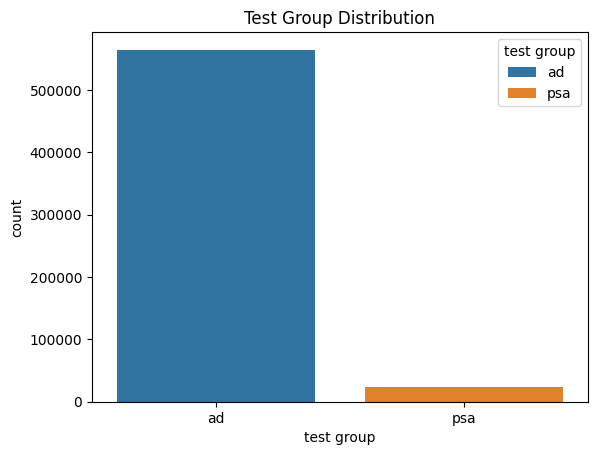

In [10]:
sns.countplot(df,x="test group",hue='test group',legend=True)
plt.title("Test Group Distribution")
plt.show()

Approzimately 96% of users are from advertise ment group and 4% belongs to the PSA group indicating imbalance

### 1. Identifying which test group does the converted users belong

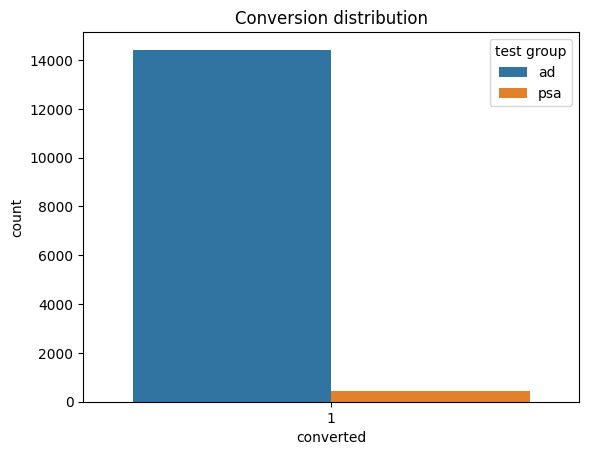

In [11]:
sns.countplot(df[df["converted"]!=0],x="converted",hue="test group")
plt.title("Conversion distribution")
plt.show()

The advertisement group records more conversions due to more no of records than psa.

In [13]:
day_ad=df.groupby(["most ads day","test group"])["converted"].sum().unstack()
day_ad

test group,ad,psa
most ads day,,
Friday,1995,62
Monday,2778,79
Saturday,1679,40
Sunday,2027,63
Thursday,1711,79
Tuesday,2270,42
Wednesday,1963,55


In [14]:
day_ad=df.groupby(["most ads day","test group"])["converted"].mean().unstack()
day_ad

test group,ad,psa
most ads day,,
Friday,0.022465,0.016303
Monday,0.033241,0.022559
Saturday,0.021307,0.013996
Sunday,0.024620,0.020595
Thursday,0.021637,0.020230
Tuesday,0.030440,0.014448
Wednesday,0.025356,0.015759


### 2. Conversion distribution across week

Text(0.5, 1.0, 'Conversion rate by day wise by test wise')

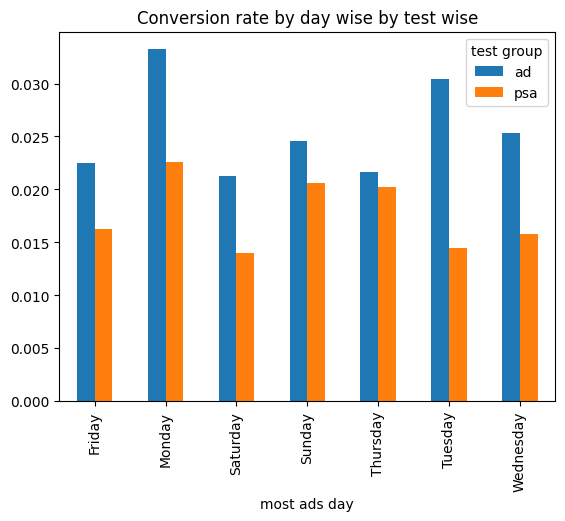

In [15]:
day_ad.plot(kind="bar")
plt.title("Conversion rate by day wise by test wise")

Advertisements acheived higher conversations at any day than PSA across the week. Tuesday showed highest uplift

In [16]:
df.groupby("most ads day")["total ads"].mean()

most ads day
Friday       26.612129
Monday       25.328517
Saturday     25.227663
Sunday       24.403661
Thursday     23.428852
Tuesday      23.925464
Wednesday    24.539205
Name: total ads, dtype: float64

### 3. Ad Exposure

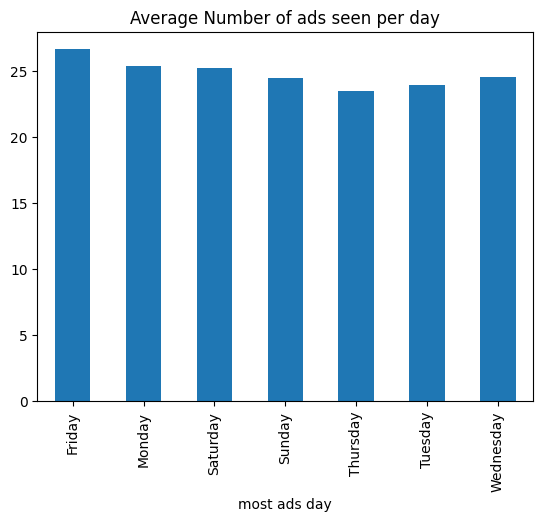

In [17]:
df.groupby("most ads day")["total ads"].mean().plot(kind="bar")
plt.title("Average Number of ads seen per day")
plt.show()

Conversion rates generally increased with greater advertisement exposure. However, the no of ads shown are constant across the week.

In [18]:
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,0,130,Monday,20
1,1119715,ad,0,93,Tuesday,22
2,1144181,ad,0,21,Tuesday,18
3,1435133,ad,0,355,Tuesday,10
4,1015700,ad,0,276,Friday,14


In [19]:
hour_summary=df.groupby(["most ads hour","test group"])["converted"].mean().unstack()
hour_summary

test group,ad,psa
most ads hour,,
0,0.019213,0.000000
1,0.013434,0.000000
2,0.007570,0.000000
3,0.010425,0.011236
4,0.015850,0.000000
5,0.021563,0.000000
6,0.023174,0.000000
7,0.018482,0.008439
8,0.019861,0.010622


### 4. Hour-wise Analysis

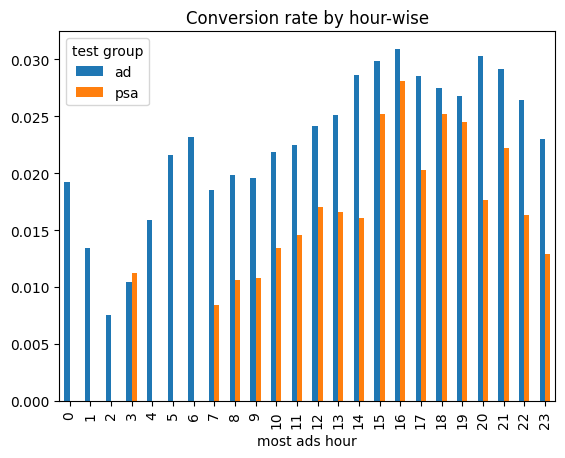

In [20]:
hour_summary.plot(kind="bar")
plt.title("Conversion rate by hour-wise")
plt.show()

Conversion rates due to ADS remain consistently higher than PSA. Users exposed to advertisements during the afternoon and evening exhibited higher conversion rates than those exposed during early morning hours. Suggesting user engagement may vary due the time of the day

In [21]:
df["total ads"].describe()

count    588101.000000
mean         24.820876
std          43.715181
min           1.000000
25%           4.000000
50%          13.000000
75%          27.000000
max        2065.000000
Name: total ads, dtype: float64

### 5. Total Ads

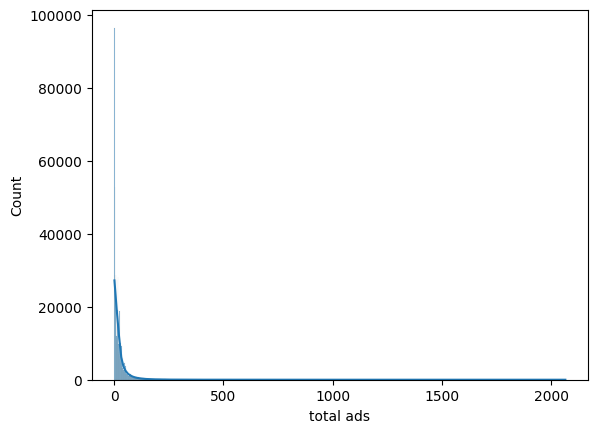

In [22]:
sns.histplot(df["total ads"],kde=True)
plt.show()

In [23]:
import numpy as np

thre=np.arange(0,1,0.1)

for x in thre:
    print(f"{x*100}% : {df["total ads"].quantile(x)}")

0.0% : 1.0
10.0% : 2.0
20.0% : 3.0
30.000000000000004% : 5.0
40.0% : 8.0
50.0% : 13.0
60.00000000000001% : 17.0
70.0% : 24.0
80.0% : 33.0
90.0% : 57.0


In [26]:
th=np.arange(0.9,1,0.001)

for x in th:
    print(f"{x*100}% : {df["total ads"].quantile(x)}")

90.0% : 57.0
90.10000000000001% : 57.0
90.2% : 57.0
90.3% : 58.0
90.4% : 58.0
90.5% : 59.0
90.60000000000001% : 59.0
90.7% : 60.0
90.8% : 60.0
90.9% : 60.0
91.0% : 61.0
91.10000000000001% : 61.0
91.2% : 62.0
91.3% : 62.0
91.4% : 63.0
91.5% : 63.0
91.60000000000001% : 64.0
91.7% : 64.0
91.8% : 65.0
91.9% : 65.0
92.0% : 66.0
92.10000000000001% : 66.0
92.2% : 67.0
92.30000000000001% : 67.0
92.4% : 68.0
92.5% : 69.0
92.60000000000001% : 69.0
92.7% : 70.0
92.80000000000001% : 70.0
92.9% : 71.0
93.0% : 72.0
93.10000000000001% : 72.0
93.2% : 73.0
93.30000000000001% : 74.0
93.4% : 74.0
93.5% : 75.0
93.60000000000001% : 76.0
93.7% : 76.0
93.80000000000001% : 77.0
93.9% : 78.0
94.0% : 79.0
94.10000000000001% : 79.0
94.2% : 80.0
94.30000000000001% : 81.0
94.4% : 82.0
94.5% : 83.0
94.60000000000001% : 84.0
94.7% : 85.0
94.80000000000001% : 86.0
94.9% : 87.0
95.0% : 88.0
95.10000000000001% : 89.0
95.2% : 90.0
95.30000000000001% : 91.0
95.4% : 92.0
95.5% : 93.0
95.60000000000001% : 94.0
95.7% : 95.0

In [27]:
df["total ads"].max()

np.int64(2065)

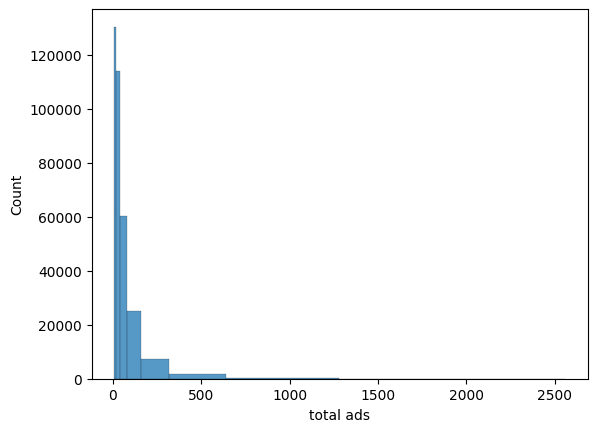

In [31]:
bins=[10,20,40,80,160,320,640,1280,2560]

sns.histplot(df,x="total ads",bins=bins)
plt.show()

In [66]:
def bin_bucket(x):
    if x in range(0,10):
        return "0-10"
    elif x in range(10,21):
        return "10-20"
    elif x in range(20,41):
        return "20-40"
    elif x in range(40,81):
        return "40-80"
    elif x in range(80,161):
        return "80-160"
    elif x in range(160,321):
        return "160-320"
    elif x in range(320,641):
        return "320-640"
    elif x in range(640,2100):
        return "640-2100"
    else:
        return "1280+"


In [67]:
df["bin_bucket"]=df["total ads"].apply(bin_bucket)

In [68]:
df["bin_bucket"].value_counts()

bin_bucket
0-10        248910
10-20       139349
20-40       107635
40-80        58209
80-160       24595
160-320       7342
320-640       1805
640-2100       256
Name: count, dtype: int64

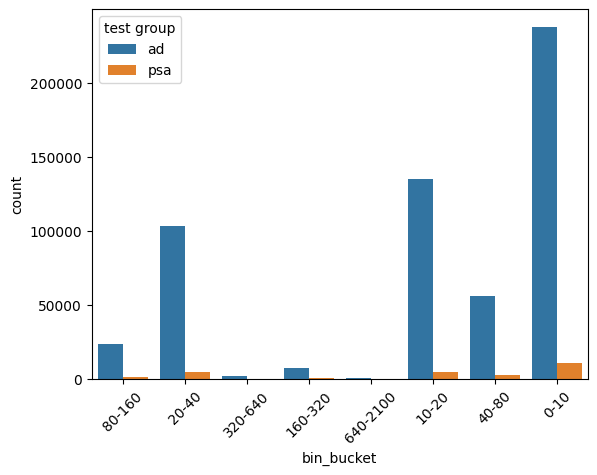

In [69]:
sns.countplot(df,x="bin_bucket",hue="test group")
plt.xticks(rotation=45)
plt.show()

Most users were exposed to fewer than 20 advertisements, while progressively fewer users received higher advertisement exposure. This indicates a highly right-skewed distribution, with only a small proportion of users experiencing very high advertisement frequencies.

In [70]:
df.groupby("bin_bucket")["converted"].mean()

bin_bucket
0-10        0.003134
10-20       0.008238
160-320     0.156224
20-40       0.023087
320-640     0.160665
40-80       0.083183
640-2100    0.187500
80-160      0.166823
Name: converted, dtype: float64

In [71]:
df.groupby("bin_bucket").agg(
    users=("converted", "count"),
    conversions=("converted", "sum"),
    conversion_rate=("converted", "mean")
)

,users,conversions,conversion_rate
bin_bucket,,,
0-10,248910,780,0.003134
10-20,139349,1148,0.008238
160-320,7342,1147,0.156224
20-40,107635,2485,0.023087
320-640,1805,290,0.160665
40-80,58209,4842,0.083183
640-2100,256,48,0.187500
80-160,24595,4103,0.166823


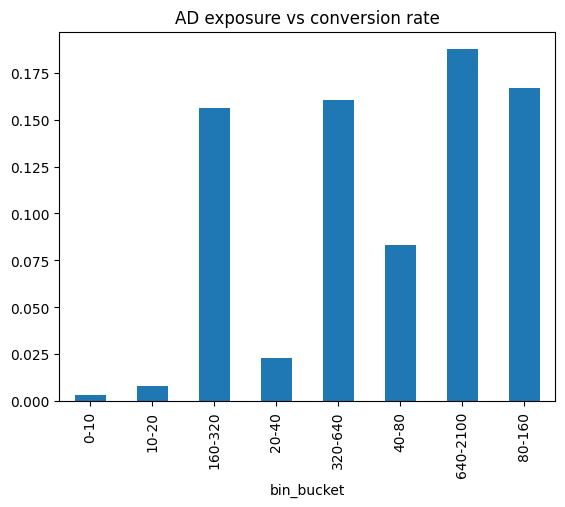

In [73]:
df.groupby("bin_bucket")["converted"].mean().plot(kind="bar")
plt.title("AD exposure vs conversion rate")
plt.show()

### Statistical Significance

Although the advertisement group exhibits a higher observed conversion rate, we need to determine whether this improvement is statistically significant or could have occurred due to random sampling variability.

To answer this question, we perform a one-sided two-proportion z-test.

In [12]:
summary=df.groupby("test group").agg(users=("converted","count"),conversion=("converted","sum"),conversion_rate=("converted","mean"))
summary

,users,conversion,conversion_rate
test group,,,
ad,564577,14423,0.025547
psa,23524,420,0.017854


In [47]:
control=summary.loc["psa", "conversion_rate"]
treatment=summary.loc["ad", "conversion_rate"]
print(control,treatment)

0.01785410644448223 0.025546559636683747


In [58]:
absolute= treatment-control
relative= (treatment-control)/control
print("Absolute Lift: ", absolute*100)
print("Relative Lift: ",relative*100)

Absolute Lift:  0.7692453192201517
Relative Lift:  43.085064022225836


In [49]:
summary

,users,conversion,conversion_rate
test group,,,
ad,564577,14423,0.025547
psa,23524,420,0.017854


In [50]:
from statsmodels.stats.proportion import proportions_ztest

counts=summary["conversion"].values
nobs=summary["users"].values

In [51]:
counts

array([14423,   420])

In [52]:
z_score,p_value=proportions_ztest(counts,nobs,alternative="larger")

In [53]:
print(z_score,p_value)

7.3700781265454145 8.526403580779863e-14


In [54]:
p_value<0.05

np.True_

In [55]:
from statsmodels.stats.proportion import confint_proportions_2indep

c1,n1=counts[0],nobs[0]
c2,n2=counts[1],nobs[1]

low,upper=confint_proportions_2indep(c1,n1,c2,n2)

print(f"Lower: {low:.2%}, Upper: {upper:.2%} ")

Lower: 0.59%, Upper: 0.94% 


The advertisement group achieved an observed absolute lift of 0.77 percentage points, corresponding to a 43.09% relative improvement over the PSA group. The two-proportion z-test indicates that this difference is statistically significant (p < 0.05). Furthermore, the 95% confidence interval for the absolute lift ranges from 0.59 to 0.94 percentage points, suggesting that the true improvement is consistently positive.

# Final Recommendation

Based on the A/B experiment, the advertisement strategy significantly outperformed the PSA.

Key Findings

• Absolute Lift: 0.77 percentage points

• Relative Lift: 43.09%

• Statistically significant improvement (p < 0.05)

• 95% Confidence Interval:
0.59–0.94 percentage points

Recommendation

Deploy the advertisement strategy while continuing to monitor long-term performance. Future experiments should investigate the optimal advertisement frequency and timing through randomized exposure experiments.